# California Yoga Studio Reviews
## Notebook 3: Exploratory Data Analysis
*2026-05*

This notebook explores 423 California yoga studios and 13,938 Google Reviews,
structured around business questions relevant to yoga studio owners.

**Input:** `yoga_studios_meta.pkl`, `yoga_reviews.pkl`
**Output:** `yoga_studios_meta.pkl` — updated with derived columns
(precise ratings, sentiment scores, opening hours flags)

**Business questions explored:**
- How do California yoga studios perform overall in terms of ratings?
- Does review volume correlate with quality?
- Which studios stand out by volume and rating?
- What distinguishes permanently closed studios from active ones?
- Where are studios geographically concentrated?
- How has review activity changed over time?
- Do opening hours correlate with ratings?
- Do reviewers who attach photos rate differently?
- Do longer reviews tend to be more negative?

## Setup

In [ ]:
# imports
from google.colab import drive

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, kruskal
from collections import Counter
from matplotlib.patches import Patch

In [ ]:
# mounting google drive
drive.mount('/content/gdrive', force_remount=True)

PROJECT_DIR = '/content/gdrive/MyDrive/YogaStudioReviews'

yoga_meta = pd.read_pickle(os.path.join(PROJECT_DIR, 'yoga_studios_meta.pkl'))
yoga_reviews = pd.read_pickle(os.path.join(PROJECT_DIR, 'yoga_reviews.pkl'))


print(f'Loaded {len(yoga_meta)} studios and {len(yoga_reviews):,} reviews')

Mounted at /content/gdrive
Loaded 423 studios and 13,938 reviews


## Dataset overview
A quick reference for all available columns — dtype, coverage, and sample values.

In [ ]:
def print_overview(df, title):
    print(f'=== {title} ===')
    print(f'Shape: {df.shape}')
    print(f'\n  {"Column":<23} {"Dtype":<12} {"Non-null":<20} {"Sample value"}')
    print('  ' + '-' * 75)
    for col in df.columns:
        non_null = df[col].notna().sum()
        pct = non_null / len(df) * 100
        dtype = str(df[col].dtype)
        sample = df[col].dropna().iloc[0] if non_null > 0 else 'N/A'
        sample_str = str(sample)[:40] + '...' if len(str(sample)) > 40 else str(sample)
        print(f'  {col:<23} {dtype:<12} {non_null:>5}/{len(df)} ({pct:>5.1f}%)  {sample_str}')

print_overview(yoga_meta, 'METADATA OVERVIEW')
print()
print_overview(yoga_reviews, 'REVIEWS OVERVIEW')

=== METADATA OVERVIEW ===
Shape: (423, 22)

  Column                  Dtype        Non-null             Sample value
  ---------------------------------------------------------------------------
  name                    object         423/423 (100.0%)  iYoga Transformation
  address                 object         417/423 ( 98.6%)  iYoga Transformation, 11887 Evergold St,...
  gmap_id                 object         423/423 (100.0%)  0x80dbfbda7e279df3:0x77fb2b251fb8b757
  description             object         106/423 ( 25.1%)  Studio offering Vinyasa, gentle, aerial ...
  latitude                float64        423/423 (100.0%)  32.9340827
  longitude               float64        423/423 (100.0%)  -117.0706208
  category                object         423/423 (100.0%)  ['Yoga studio', 'Life coach', 'Massage t...
  avg_rating              float64        423/423 (100.0%)  4.7
  num_of_reviews          int64          423/423 (100.0%)  8
  price                   object          14/423 (  3

## Derived columns and convenience subsets

Create additional columns used throughout the analysis and define
convenience subsets for active and closed studios.

In [ ]:
# Derived columns
yoga_reviews['date'] = pd.to_datetime(yoga_reviews['time'], unit='ms')
yoga_reviews['year'] = yoga_reviews['date'].dt.year
yoga_reviews['has_photo'] = yoga_reviews['pic_count'] > 0
yoga_reviews['text_length'] = yoga_reviews['text'].str.len()

yoga_meta['status'] = yoga_meta['state'].str.contains(
    'permanently closed', case=False, na=False
).map({True: 'Closed', False: 'Active'})

# Convenience subsets
active = yoga_meta[yoga_meta['status'] == 'Active']
closed = yoga_meta[yoga_meta['status'] == 'Closed']
reviews_text = yoga_reviews[yoga_reviews['text'].notna()].copy()

print(f'Loaded {len(yoga_meta)} studios and {len(yoga_reviews):,} reviews')
print(f'Active: {len(active)} | Closed: {len(closed)}')
print(f'Reviews with text: {len(reviews_text):,}')

Loaded 423 studios and 13,938 reviews
Active: 360 | Closed: 63
Reviews with text: 10,547


## Rating overview

**Business question:** How do California yoga studios perform overall,
and is the rating distribution what we'd expect?

- What is the distribution of average studio ratings?
- What is the distribution of individual review ratings?

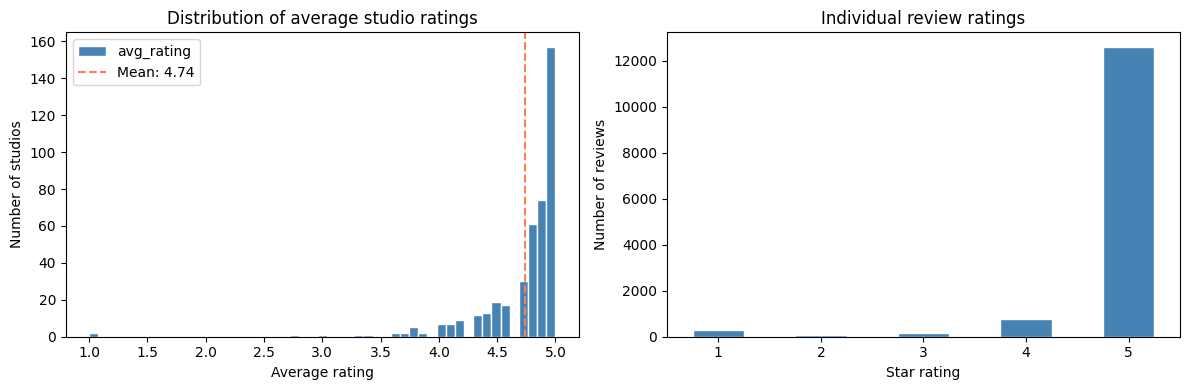

=== Rating summary ===
Mean studio rating:        4.74
Studios rated 5.0:         157
Studios rated 4.5+:        358
Studios rated below 4.0:   17
Studios rated below 3.0:   3


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Distribution of average studio ratings
yoga_meta['avg_rating'].dropna().plot(
    kind='hist', bins='fd',
    ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Distribution of average studio ratings')
axes[0].set_xlabel('Average rating')
axes[0].set_ylabel('Number of studios')
axes[0].axvline(
    yoga_meta['avg_rating'].mean(),
    color='coral', linestyle='--',
    label=f'Mean: {yoga_meta["avg_rating"].mean():.2f}'
)
axes[0].legend()

# 2. Individual review rating distribution
yoga_reviews['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1],
    color='steelblue', edgecolor='white'
)
axes[1].set_title('Individual review ratings')
axes[1].set_xlabel('Star rating')
axes[1].set_ylabel('Number of reviews')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('=== Rating summary ===')
print(f'Mean studio rating:        {yoga_meta["avg_rating"].mean():.2f}')
print(f'Studios rated 5.0:         {(yoga_meta["avg_rating"] == 5.0).sum()}')
print(f'Studios rated 4.5+:        {(yoga_meta["avg_rating"] >= 4.5).sum()}')
print(f'Studios rated below 4.0:   {(yoga_meta["avg_rating"] < 4.0).sum()}')
print(f'Studios rated below 3.0:   {(yoga_meta["avg_rating"] < 3.0).sum()}')

In [ ]:
# Are perfect 5.0 studios just low review count studios?
perfect = yoga_meta[yoga_meta['avg_rating'] == 5.0]
non_perfect = yoga_meta[yoga_meta['avg_rating'] < 5.0]
diff_pct = (non_perfect['num_of_reviews'].mean() - perfect['num_of_reviews'].mean()) / non_perfect['num_of_reviews'].mean() * 100

print(f'Mean reviews for 5.0 studios:     {perfect["num_of_reviews"].mean():.1f}')
print(f'Mean reviews for non-5.0 studios: {non_perfect["num_of_reviews"].mean():.1f}')
print(f'Non-5.0 studios have {diff_pct:.0f}% more reviews on average')

Mean reviews for 5.0 studios:     27.4
Mean reviews for non-5.0 studios: 36.7
Non-5.0 studios have 25% more reviews on average


## Precise average ratings

Google's `avg_rating` is pre-computed and rounded. The precise averages are calculated directly from our filtered review dataset for more accurate analysis later.

**Note:** precise averages reflect the filtered dataset (reviews up to
October 2021), while Google's `avg_rating` covers all reviews ever
received. Both are valid but measure slightly different things.

In [ ]:
# Calculate precise average ratings from actual reviews
precise_ratings = (
    yoga_reviews
    .groupby('gmap_id')['rating']
    .agg(
        precise_avg=('mean'),
        review_count=('count')
    )
    .reset_index()
)

# Merge back into metadata, keeping original avg_rating for comparison
yoga_meta = yoga_meta.merge(precise_ratings, on='gmap_id', how='left')

print('=== Rating precision comparison ===')
print(f'Studios with precise ratings: {yoga_meta["precise_avg"].notna().sum()}')
print(f'Studios without reviews in our dataset: {yoga_meta["precise_avg"].isna().sum()}')
print(f'\nOriginal avg_rating mean:  {yoga_meta["avg_rating"].mean():.4f}')
print(f'Precise avg_rating mean:   {yoga_meta["precise_avg"].mean():.4f}')
print(f'\nSample comparison (first 10 studios):')
print(yoga_meta[['name', 'avg_rating', 'precise_avg', 'num_of_reviews', 'review_count']].head(15).to_string(index=False))

=== Rating precision comparison ===
Studios with precise ratings: 423
Studios without reviews in our dataset: 0

Original avg_rating mean:  4.7383
Precise avg_rating mean:   4.7366

Sample comparison (first 10 studios):
                           name  avg_rating  precise_avg  num_of_reviews  review_count
           iYoga Transformation         4.7     4.500000               8             8
      Soulstice Mind + Body Spa         4.9     4.852941              34            34
Seventh Chakra Yoga - Placentia         4.0     4.000000               4             4
                ASTRO GONG YOGA         5.0     4.937500              18            16
               Beach House Yoga         5.0     5.000000               2             2
         Delaram Raisdana, L.Ac         5.0     5.000000               1             1
                   Yoga Central         4.8     4.800000               5             5
               Home Yoga Studio         5.0     5.000000              34            

### Insight — Ratings are strongly skewed toward 5 stars

Google Reviews has a well-documented positivity bias — people tend to review places they liked. Yoga studio customers are particularly self-selected. A mean of 4.74 is high but expected for this category.

Studios rated exactly 5.0 have on average 25% fewer reviews than lower-rated studios (27.4 vs 36.7), suggesting perfect scores might be more common among
newer or quieter studios.

**Implication:** a high rating combined with high review volume might be a strongersignal of consistent quality than a perfect score alone.

## Review volume

**Business question:** Which studios attract the most reviews,
and does popularity correlate with quality?

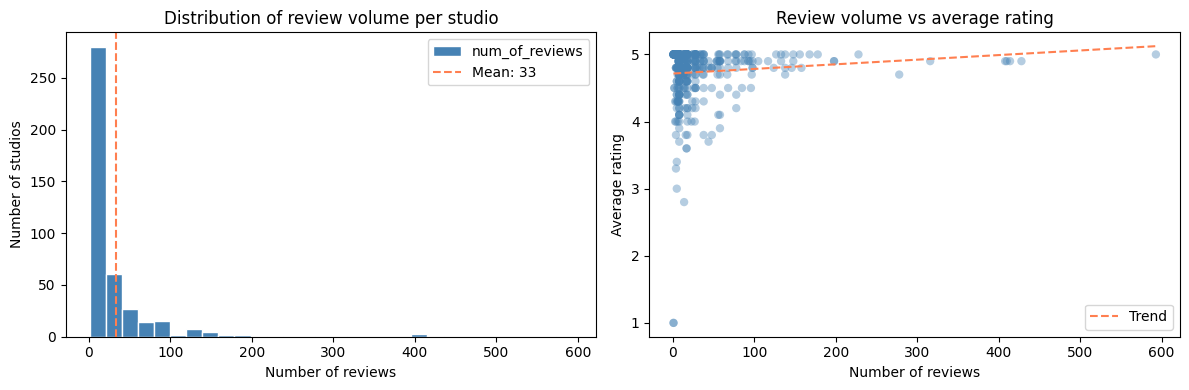

=== Review volume summary ===
Mean reviews per studio:     33.2
Median reviews per studio:   15.0
Studios with 1-10 reviews:   188
Studios with 11-50 reviews:  161
Studios with 51-100 reviews: 48
Studios with 100+ reviews:   26
Most reviewed studio:        593 reviews
Least reviewed studio:       1 reviews

Correlation volume vs rating: 0.099


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Review volume distribution
yoga_meta['num_of_reviews'].plot(
    kind='hist', bins=30, ax=axes[0],
    color='steelblue', edgecolor='white'
)
axes[0].set_title('Distribution of review volume per studio')
axes[0].set_xlabel('Number of reviews')
axes[0].set_ylabel('Number of studios')
axes[0].axvline(
    yoga_meta['num_of_reviews'].mean(),
    color='coral', linestyle='--',
    label=f'Mean: {yoga_meta["num_of_reviews"].mean():.0f}'
)
axes[0].legend()

# 2. Review volume vs average rating scatter with trend line
mask = yoga_meta['num_of_reviews'].notna() & yoga_meta['avg_rating'].notna()
x = yoga_meta.loc[mask, 'num_of_reviews']
y = yoga_meta.loc[mask, 'avg_rating']

axes[1].scatter(x, y, alpha=0.4, color='steelblue', edgecolors='none')
z = np.polyfit(x, y, 1)
p_fit = np.poly1d(z)
axes[1].plot(sorted(x), p_fit(sorted(x)),
             color='coral', linestyle='--', linewidth=1.5, label='Trend')
axes[1].set_title('Review volume vs average rating')
axes[1].set_xlabel('Number of reviews')
axes[1].set_ylabel('Average rating')
axes[1].legend()

plt.tight_layout()
plt.show()

corr = yoga_meta['num_of_reviews'].corr(yoga_meta['avg_rating'])

print('=== Review volume summary ===')
print(f'Mean reviews per studio:     {yoga_meta["num_of_reviews"].mean():.1f}')
print(f'Median reviews per studio:   {yoga_meta["num_of_reviews"].median():.1f}')
print(f'Studios with 1-10 reviews:   {((yoga_meta["num_of_reviews"] >= 1) & (yoga_meta["num_of_reviews"] <= 10)).sum()}')
print(f'Studios with 11-50 reviews:  {((yoga_meta["num_of_reviews"] > 10) & (yoga_meta["num_of_reviews"] <= 50)).sum()}')
print(f'Studios with 51-100 reviews: {((yoga_meta["num_of_reviews"] > 50) & (yoga_meta["num_of_reviews"] <= 100)).sum()}')
print(f'Studios with 100+ reviews:   {(yoga_meta["num_of_reviews"] > 100).sum()}')
print(f'Most reviewed studio:        {yoga_meta["num_of_reviews"].max():.0f} reviews')
print(f'Least reviewed studio:       {yoga_meta["num_of_reviews"].min():.0f} reviews')
print(f'\nCorrelation volume vs rating: {corr:.3f}')

## Top studios

**Business question:** Which studios stand out by review volume and by rating,
and what can we learn from them?

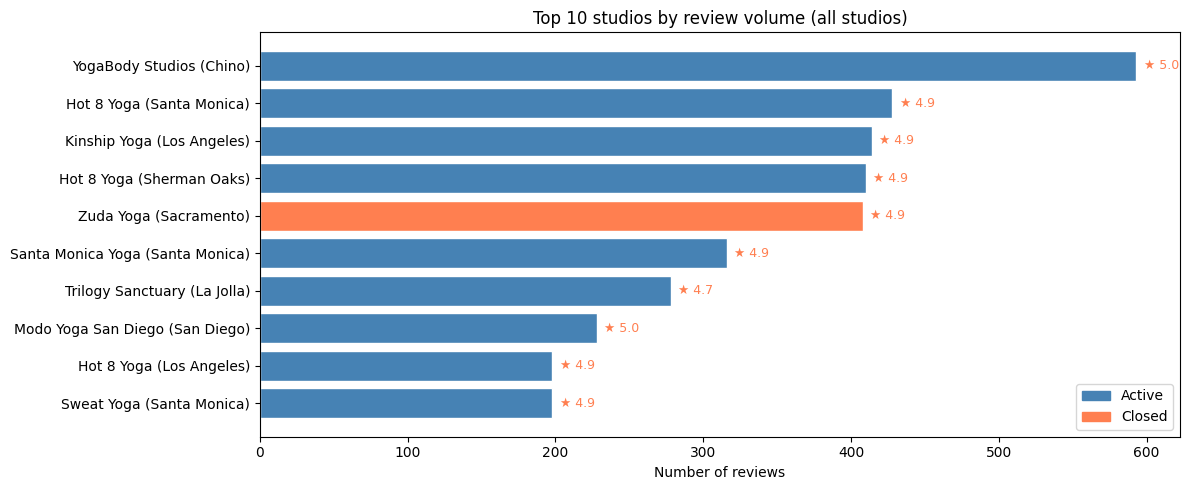

Top 10 studios by review volume:
                    display_name  num_of_reviews  avg_rating status
        YogaBody Studios (Chino)             593         5.0 Active
       Hot 8 Yoga (Santa Monica)             428         4.9 Active
      Kinship Yoga (Los Angeles)             414         4.9 Active
       Hot 8 Yoga (Sherman Oaks)             410         4.9 Active
          Zuda Yoga (Sacramento)             408         4.9 Closed
Santa Monica Yoga (Santa Monica)             316         4.9 Active
    Trilogy Sanctuary (La Jolla)             278         4.7 Active
 Modo Yoga San Diego (San Diego)             228         5.0 Active
        Hot 8 Yoga (Los Angeles)             198         4.9 Active
       Sweat Yoga (Santa Monica)             198         4.9 Active


In [ ]:
# Top 10 studios by review volume — all studios, branches distinguished by location
yoga_meta['city'] = yoga_meta['address'].str.extract(r',\s*([^,]+),\s*CA')
yoga_meta['display_name'] = yoga_meta.apply(
    lambda row: f"{row['name']} ({row['city']})"
    if pd.notna(row['city']) else row['name'],
    axis=1
)

top_volume = yoga_meta.nlargest(10, 'num_of_reviews')[
    ['display_name', 'num_of_reviews', 'avg_rating', 'status']
]

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['steelblue' if s == 'Active' else 'coral' for s in top_volume['status']]
bars = ax.barh(top_volume['display_name'], top_volume['num_of_reviews'],
               color=colors, edgecolor='white')
ax.set_title('Top 10 studios by review volume (all studios)')
ax.set_xlabel('Number of reviews')
ax.invert_yaxis()

for bar, (_, row) in zip(bars, top_volume.iterrows()):
    ax.text(
        bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
        f'★ {row["avg_rating"]:.1f}', va='center', fontsize=9, color='coral'
    )

ax.legend(handles=[
    Patch(color='steelblue', label='Active'),
    Patch(color='coral', label='Closed')
])

plt.tight_layout()
plt.show()

print('Top 10 studios by review volume:')
print(top_volume[['display_name', 'num_of_reviews', 'avg_rating', 'status']].to_string(index=False))

### Insight - Chain advantage

Hot 8 Yoga appears three times in the top 10 most reviewed
active studios, suggesting chain studios may have structural advantages over
independent operators.

YogaBody studio has 593 reviews at 5.0. It means every single reviewer gave 5 stars — which is genuinely unusual. At this volume, perfect ratings become increasingly suspicious and may warrant closer inspection of review authenticity. This was checked directly in Google maps and reviews do look legitimate.

## Active vs permanently closed studios

**Business question:** What patterns distinguish studios that closed
from those that remain active?

- Do closed studios have lower ratings?
- Do closed studios have fewer reviews?
- Is the difference significant?

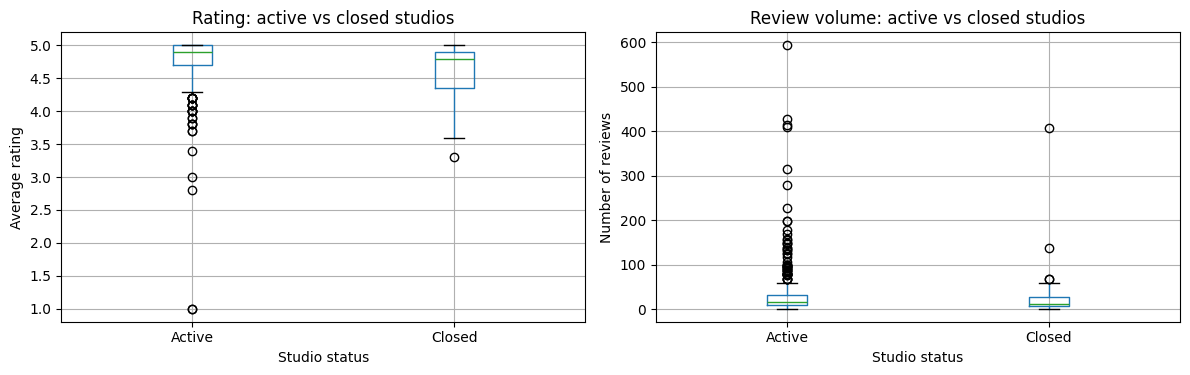

=== Active vs closed summary ===
Active studios: 360 | Closed studios: 63
Ratings:  Active mean 4.763 | Closed mean 4.600
Volume:   Active mean 34.5 | Closed mean 26.1


In [ ]:
# Closed vs. active studio review rating and volume distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

yoga_meta.boxplot(column='avg_rating', by='status', ax=axes[0])
axes[0].set_title('Rating: active vs closed studios')
axes[0].set_xlabel('Studio status')
axes[0].set_ylabel('Average rating')

yoga_meta.boxplot(column='num_of_reviews', by='status', ax=axes[1])
axes[1].set_title('Review volume: active vs closed studios')
axes[1].set_xlabel('Studio status')
axes[1].set_ylabel('Number of reviews')

plt.suptitle('')
plt.tight_layout()
plt.show()

print('=== Active vs closed summary ===')
print(f'Active studios: {len(active)} | Closed studios: {len(closed)}')
print(f'Ratings:  Active mean {active["avg_rating"].mean():.3f} | Closed mean {closed["avg_rating"].mean():.3f}')
print(f'Volume:   Active mean {active["num_of_reviews"].mean():.1f} | Closed mean {closed["num_of_reviews"].mean():.1f}')

### Statistical tests

Two complementary tests for each comparison:
- **t-test** — parametric, assumes roughly normal distributions and thus not conlusive on its own in for the current dataset
- **Mann-Whitney U test** — non-parametric, more robust for skewed data like ratings

Running both gives a more complete picture. If both agree, the finding is indeed robust.

In [ ]:
# Test 1 — Ratings: active vs closed
a_ratings = active['avg_rating'].dropna()
c_ratings = closed['avg_rating'].dropna()

t_stat, p_ttest = stats.ttest_ind(a_ratings, c_ratings)
u_stat, p_mwu = stats.mannwhitneyu(a_ratings, c_ratings, alternative='two-sided')

print('=== Test 1: Ratings — active vs closed ===')
print(f'Active mean: {a_ratings.mean():.3f} (n={len(a_ratings)})')
print(f'Closed mean: {c_ratings.mean():.3f} (n={len(c_ratings)})')
print(f't-test:          t={t_stat:.3f}, p={p_ttest:.4f} → {"Significant" if p_ttest < 0.05 else "Not significant"}')
print(f'Mann-Whitney U:  U={u_stat:.0f}, p={p_mwu:.4f} → {"Significant" if p_mwu < 0.05 else "Not significant"}')

=== Test 1: Ratings — active vs closed ===
Active mean: 4.763 (n=360)
Closed mean: 4.600 (n=63)
t-test:          t=2.816, p=0.0051 → Significant
Mann-Whitney U:  U=14976, p=0.0000 → Significant


In [ ]:
# Test 2 — Review volume: active vs closed
a_volume = active['num_of_reviews'].dropna()
c_volume = closed['num_of_reviews'].dropna()

t_stat_v, p_ttest_v = stats.ttest_ind(a_volume, c_volume)
u_stat_v, p_mwu_v = stats.mannwhitneyu(a_volume, c_volume, alternative='two-sided')

print('=== Test 2: Review volume — active vs closed ===')
print(f'Active mean: {a_volume.mean():.1f} (n={len(a_volume)})')
print(f'Closed mean: {c_volume.mean():.1f} (n={len(c_volume)})')
print(f't-test:          t={t_stat_v:.3f}, p={p_ttest_v:.4f} → {"Significant" if p_ttest_v < 0.05 else "Not significant"}')
print(f'Mann-Whitney U:  U={u_stat_v:.0f}, p={p_mwu_v:.4f} → {"Significant" if p_mwu_v < 0.05 else "Not significant"}')

=== Test 2: Review volume — active vs closed ===
Active mean: 34.5 (n=360)
Closed mean: 26.1 (n=63)
t-test:          t=1.006, p=0.3152 → Not significant
Mann-Whitney U:  U=12195, p=0.3369 → Not significant


### Insight — Lower ratings are a statistically significant signal of closure risk

Active studios average 4.76 stars vs 4.60 for permanently closed studios. This difference might not look big but both the t-test and Mann-Whitney U test confirm that it is statistically significant.

**Implication:** consistently maintaining high ratings may be an indicator of long-term business viability.

### Insight — Review volume does not distinguish closed from active studios

Closed studios average 26 reviews vs 35 for active studios. Neither test
finds this significant, suggesting that how well a studio is rated matters
more than how many reviews it has accumulated over time.

## Reviews over time

**Business question:** Has yoga review activity grown over the years,
and when did our dataset peak?

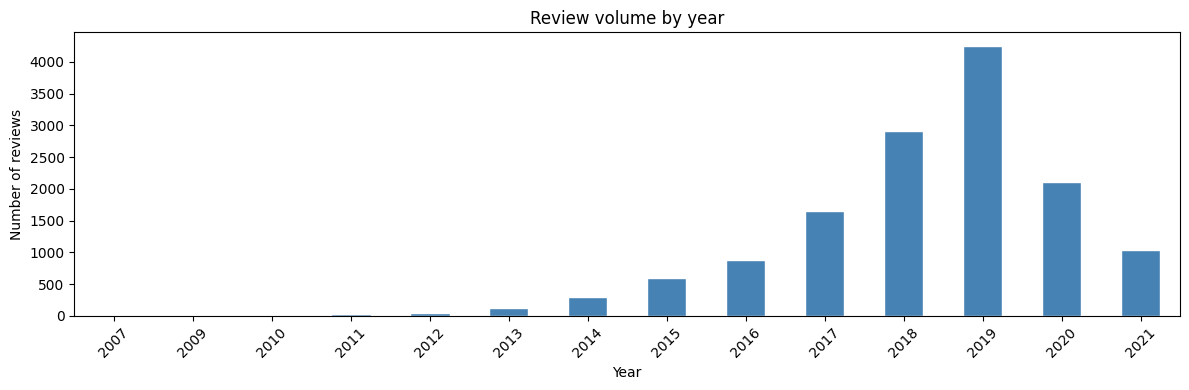

=== Review volume by year ===
year
2007       1
2009       1
2010       7
2011      26
2012      42
2013     128
2014     302
2015     596
2016     877
2017    1659
2018    2908
2019    4251
2020    2105
2021    1035

Peak year: 2019 (4,251 reviews)
Earliest review: 2007-11-05
Latest review:   2021-08-29


In [ ]:
yearly = yoga_reviews.groupby('year').size()

fig, ax = plt.subplots(figsize=(12, 4))
yearly.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Review volume by year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of reviews')
# One tick per year
ax.set_xticks(range(len(yearly)))
ax.set_xticklabels(yearly.index, rotation=45)

plt.tight_layout()
plt.show()

print('=== Review volume by year ===')
print(yearly.to_string())
print(f'\nPeak year: {yearly.idxmax()} ({yearly.max():,} reviews)')
print(f'Earliest review: {yoga_reviews["date"].min().date()}')
print(f'Latest review:   {yoga_reviews["date"].max().date()}')

### Insight — Review activity peaked in 2019 and dropped sharply during COVID-19

Review volume grew consistently from 2007 to 2019, reflecting the broader
rise of Google Reviews as a platform and the expansion of the California
yoga market. The dataset peaks in 2019 with 4,251 reviews before dropping
sharply in 2020 — a 50% decline directly attributable to COVID-19 studio closures and capacity restrictions. Volume continued to fall in 2021, with the dataset snapshot taken in August 2021 before the full post-pandemic recovery.

**Dataset limitation:** the snapshot ends in August 2021, capturing the COVID downturn but not the recovery. Post-pandemic data (2022–2026) would be valuable — both to assess whether review volumes returned to pre-COVID levels.

**Implication for analysis:** the 2020–2021 reviews reflect an atypical period yoga business. Sentiment and topic patterns in these years may differ from normal operating conditions and should be interpreted with this context in mind.

## Opening hours analysis

**Business question:** How do California yoga studios structure their opening hours,
and do studios open on weekends rate differently from those that do not?

In [ ]:
# column value sample
yoga_meta['hours']

,hours
0,"[[Thursday, Open 24 hours], [Friday, Open 24 h..."
1,"[[Wednesday, 12–7PM], [Thursday, Closed], [Fri..."
2,"[[Monday, 6:30–7:30PM], [Tuesday, 11AM–12:30PM..."
3,"[[Monday, Closed], [Tuesday, 8:30AM–2PM], [Wed..."
4,None
...,...
418,"[[Thursday, 7AM–11:11PM], [Friday, 7AM–11:11PM..."
419,"[[Monday, 12:30–8PM], [Tuesday, 12:30–8PM], [W..."
420,"[[Friday, 7AM–9PM], [Saturday, 7:30AM–6:30PM],..."
421,"[[Wednesday, 8AM–7PM], [Thursday, 8AM–7PM], [F..."


/tmp/ipykernel_697/1040631998.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


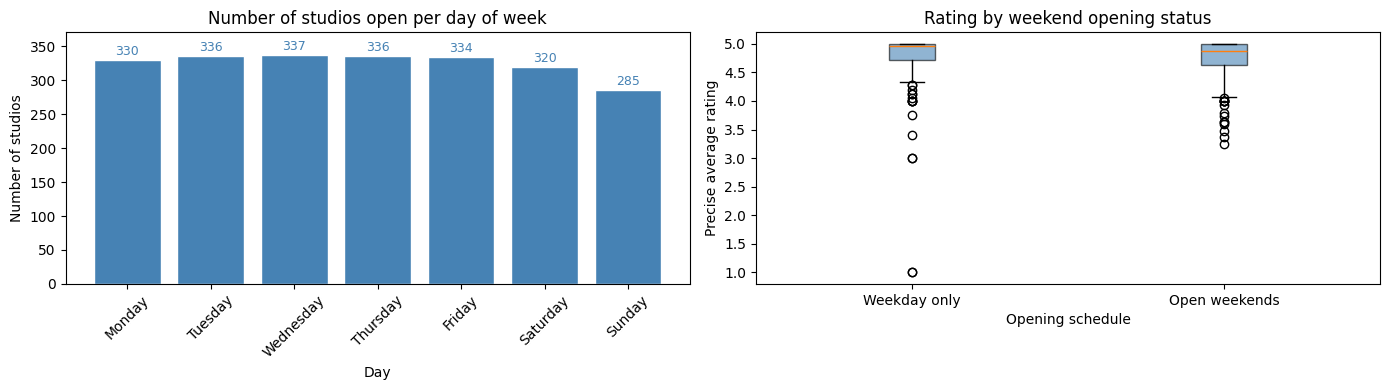

=== Opening hours summary ===
Studios with hours data:   349 of 423
Actually open Saturday:    320
Actually open Sunday:      285
Open both weekend days:    281

Mean rating open weekends:  4.743 (n=281)
Mean rating weekday only:   4.725 (n=142)


In [ ]:
# Which days do studios actually operate (excluding 'Closed' entries)?
day_counts = Counter()
for hours_list in yoga_meta['hours'].dropna():
    for day, hours in hours_list:
        if hours.strip().lower() != 'closed':
            day_counts[day] += 1

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_values = [day_counts.get(d, 0) for d in day_order]

# Weekend opening flag — only count as open if hours is not 'Closed'
def is_open_on(hours_list, day):
    if not hours_list:
        return False
    return any(
        d == day and hours.strip().lower() != 'closed'
        for d, hours in hours_list
    )

yoga_meta['open_saturday'] = yoga_meta['hours'].apply(lambda h: is_open_on(h, 'Saturday'))
yoga_meta['open_sunday'] = yoga_meta['hours'].apply(lambda h: is_open_on(h, 'Sunday'))
yoga_meta['open_weekend'] = yoga_meta['open_saturday'] & yoga_meta['open_sunday']

weekend_ratings = yoga_meta[yoga_meta['open_weekend'] == True]['precise_avg'].dropna()
weekday_ratings = yoga_meta[yoga_meta['open_weekend'] == False]['precise_avg'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 1. Studios actually open per day
bars = axes[0].bar(day_order, day_values, color='steelblue', edgecolor='white')
axes[0].set_title('Number of studios open per day of week')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Number of studios')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, max(day_values) * 1.1)

# Add count labels on top of each bar
for bar, value in zip(bars, day_values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        str(value),
        ha='center', va='bottom', fontsize=9, color='steelblue')

# 2. Weekend opening vs rating — boxplot
axes[1].boxplot(
    [weekday_ratings, weekend_ratings],
    labels=['Weekday only', 'Open weekends'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)
axes[1].set_title('Rating by weekend opening status')
axes[1].set_xlabel('Opening schedule')
axes[1].set_ylabel('Precise average rating')

plt.tight_layout()
plt.show()

print('=== Opening hours summary ===')
print(f'Studios with hours data:   {yoga_meta["hours"].notna().sum()} of {len(yoga_meta)}')
print(f'Actually open Saturday:    {yoga_meta["open_saturday"].sum()}')
print(f'Actually open Sunday:      {yoga_meta["open_sunday"].sum()}')
print(f'Open both weekend days:    {yoga_meta["open_weekend"].sum()}')
print(f'\nMean rating open weekends:  {weekend_ratings.mean():.3f} (n={len(weekend_ratings)})')
print(f'Mean rating weekday only:   {weekday_ratings.mean():.3f} (n={len(weekday_ratings)})')

## Insight — Weekend opening does not affect ratings
Studios open on both weekend days average 4.74 vs 4.73 for weekday-only
studios — basically no difference. This suggests that weekend availability
alone is not a driver of customer satisfaction.

**Implication:** opening on weekends may be necessary for revenue, but it doesn't inherently improve how customers perceive the studio experience.

## Photo reviews

**Business question:** Do reviewers who attach photos rate differently
from those who don't?

In [ ]:
has_photo_ratings = yoga_reviews[yoga_reviews['has_photo']]['rating'].dropna()
no_photo_ratings = yoga_reviews[~yoga_reviews['has_photo']]['rating'].dropna()

print('=== Photo review summary ===')
print(f'Reviews with photos:        {yoga_reviews["has_photo"].sum():,}')
print(f'Reviews without photos:     {(~yoga_reviews["has_photo"]).sum():,}')
print(f'Mean rating with photo:     {has_photo_ratings.mean():.3f}')
print(f'Mean rating without photo:  {no_photo_ratings.mean():.3f}')

=== Photo review summary ===
Reviews with photos:        257
Reviews without photos:     13,681
Mean rating with photo:     4.821
Mean rating without photo:  4.812


Only 257 out of 13,938 reviews (1.8%) include photos. The mean rating
for photo reviews (4.821) is nearly identical to non-photo reviews (4.812),
suggesting that photo reviewers are not meaningfully different in their
rating behaviour despite being more engaged.

## Review text length

**Business question:** Do longer reviews tend to be more negative?
Does reviewer engagement (text length) correlate with rating?

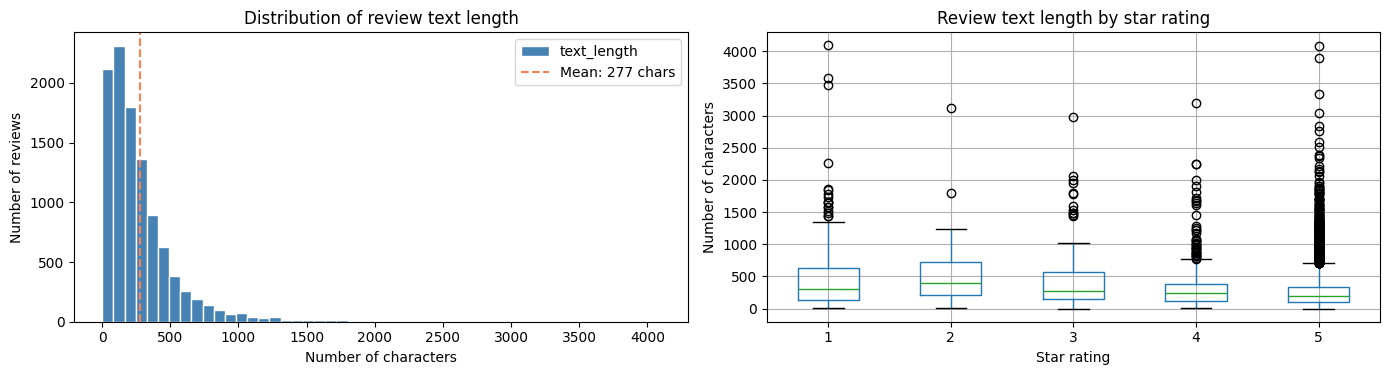

=== Text length summary ===
Mean length:    277 characters
Median length:  200 characters
Shortest:       1 characters
Longest:        4090 characters

Mean text length by rating:
rating
1    502.0
2    506.0
3    482.0
4    318.0
5    265.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 1. Text length distribution
reviews_text['text_length'].plot(
    kind='hist', bins=50, ax=axes[0],
    color='steelblue', edgecolor='white'
)
axes[0].set_title('Distribution of review text length')
axes[0].set_xlabel('Number of characters')
axes[0].set_ylabel('Number of reviews')
axes[0].axvline(
    reviews_text['text_length'].mean(),
    color='coral', linestyle='--',
    label=f'Mean: {reviews_text["text_length"].mean():.0f} chars'
)
axes[0].legend()

# 2. Text length by star rating — boxplot
reviews_text.boxplot(column='text_length', by='rating', ax=axes[1])
axes[1].set_title('Review text length by star rating')
axes[1].set_xlabel('Star rating')
axes[1].set_ylabel('Number of characters')
plt.suptitle('')

plt.tight_layout()
plt.show()

print('=== Text length summary ===')
print(f'Mean length:    {reviews_text["text_length"].mean():.0f} characters')
print(f'Median length:  {reviews_text["text_length"].median():.0f} characters')
print(f'Shortest:       {reviews_text["text_length"].min():.0f} characters')
print(f'Longest:        {reviews_text["text_length"].max():.0f} characters')
print(f'\nMean text length by rating:')
print(reviews_text.groupby('rating')['text_length'].mean().round(0).to_string())

### Insight — Dissatisfied customers write more

Review text length decreases as star rating increases.
1-star reviews average 502 characters vs 265 for 5-star reviews —
nearly twice as long. It means that unhappy customers feel the need to explain
and justify their experience, while satisfied customers leave
briefer feedback.

This has two implications:
- **For NLP:** negative reviews will carry more semantic signal per
  review than positive ones, despite being fewer in number
- **For studio owners:** short reviews signal satisfaction and not necessarily that people are less engaged with the studio activities

### Statistical tests

Two tests were chosen to measure the gradual text increase with and icreased rating category:

- **Spearman correlation** — measures whether text length consistently
  changes as rating changes across all five levels; non-parametric and
  robust to skewed distributions
- **Kruskal-Wallis test** — tests whether text length distributions
  differ significantly across all five rating categories simultaneously

In [ ]:
# Spearman correlation — does text length decrease as rating increases?

from scipy.stats import spearmanr

corr, p_value = spearmanr(
    reviews_text['rating'],
    reviews_text['text_length']
)
print(f'Spearman correlation: {corr:.3f}')
print(f'p-value: {p_value:.4f}')
print(f'Significant: {"Yes" if p_value < 0.05 else "No"}')

Spearman correlation: -0.101
p-value: 0.0000
Significant: Yes


In [ ]:
# Kruskal-Wallis — do text length distributions differ across all rating groups?
from scipy.stats import kruskal

groups = [reviews_text[reviews_text['rating'] == r]['text_length'].dropna()
          for r in [1, 2, 3, 4, 5]]

stat, p_value = kruskal(*groups)
print(f'Kruskal-Wallis H: {stat:.3f}')
print(f'p-value: {p_value:.4f}')
print(f'Significant: {"Yes" if p_value < 0.05 else "No"}')

Kruskal-Wallis H: 129.334
p-value: 0.0000
Significant: Yes


### Insight — Lower ratings are associated with longer reviews

Spearman correlation confirms a statistically significant negative relationship between rating and text length and is confirmed by Kruskal-Wallis across all five rating groups.

However the overall effect is weak, meaning rating explains only ~1% of variance in review length.

**Implication:** while the relationship is real, text length alone is
not a very reliable predictor of rating. The NLP analysis will need to explore
review content rather than length.

## Summary of key findings

| # | Finding | Evidence | Implication |
|---|---------|----------|-------------|
| 1 | Ratings strongly skewed toward 5 stars (mean 4.74) | Descriptive | Use volume-weighted ratings, not raw averages |
| 2 | Perfect 5.0 studios have 25% fewer reviews | Descriptive | High rating + high volume is a stronger quality signal |
| 3 | Closed studios have lower ratings (4.60 vs 4.76) | t-test + MWU significant | Rating is a genuine early warning signal of closure risk |
| 4 | Volume difference: active vs closed not significant | t-test + MWU not significant | Quality matters more than quantity of reviews |
| 5 | 1-star reviews are significantly longer than 5-star | t-test + MWU | Dissatisfied customers write more to explain their experience |

**Next steps:** sentiment analysis and topic modelling on review text
to understand *what* customers talk about in positive vs negative reviews.

## Save updated metadata

In [ ]:
yoga_meta.to_pickle(os.path.join(PROJECT_DIR, 'yoga_studios_meta.pkl'))
print('Metadata saved with new columns.')

Metadata saved with new columns.
